# Filter Benchmark + EfficientNetV2-L (Pretrained, Folder-Based)


In [51]:
import os
import json
import copy
import random
import warnings
from typing import Callable

import cv2
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import torchvision.transforms as T
from torchvision.models import efficientnet_v2_l

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    auc,
    classification_report,
    confusion_matrix,
)
from sklearn.preprocessing import label_binarize

warnings.filterwarnings('ignore')

DATA_ROOT = '/mounts/mecd-ap-g5/data/MIQR-CC-Dataset-splits'
RESULTS_ROOT = '/mounts/mecd-ap-g5/results'
MODELS_ROOT = '/mounts/mecd-ap-g5/models'
NOTEBOOK_NAME = 'filter_benchmark_efficientnet_v2_l_pretrained_folder'
RESULTS_DIR = os.path.join(RESULTS_ROOT, NOTEBOOK_NAME)
MODELS_DIR = os.path.join(MODELS_ROOT, NOTEBOOK_NAME)
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

SEED = 42
IMG_SIZE = 512
BATCH_SIZE = 8
NUM_WORKERS = 4
NUM_EPOCHS = 40
PATIENCE = 8
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
USE_PRETRAINED = True
GEOMETRY_MODE = 'pad_resize_if_rect'
USE_CLAHE = True

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]


def set_determinism(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_determinism(SEED)


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
    print('VRAM (GB):', torch.cuda.get_device_properties(0).total_memory / 1e9)
print('RESULTS_DIR:', RESULTS_DIR)
print('MODELS_DIR:', MODELS_DIR)

Device: cuda
GPU: NVIDIA RTX 6000 Ada Generation
VRAM (GB): 50.86216192
RESULTS_DIR: /mounts/mecd-ap-g5/results/filter_benchmark_efficientnet_v2_l_pretrained_folder
MODELS_DIR: /mounts/mecd-ap-g5/models/filter_benchmark_efficientnet_v2_l_pretrained_folder


In [52]:
# Use the original/raw dataset metadata for filtering and mapping (splits live under DATA_ROOT)
RAW_DATA_ROOT = '/mounts/mecd-ap-g5/data/MIQR-CC-Dataset'
METADATA_PATH = os.path.join(RAW_DATA_ROOT, 'metadata.csv')
print('Reading metadata from', METADATA_PATH)

df = pd.read_csv(METADATA_PATH)

EXCLUDED_LABELS = {'unlabeled', 'unlabelled', 'unlabbeled'}
FUSED_LABEL_MAP = {
    'Benign Stricture': 'Stricture',
    'Malignant Stricture': 'Stricture',
    'Biliary Leaks': 'Biliary Leaks',
    'Lithiasis': 'Lithiasis',
    'Normal': 'Normal',
}
FINAL_CLASSES = ['Biliary Leaks', 'Lithiasis', 'Normal', 'Stricture']

filtered = df[
    (df['Keep'].astype(str).str.strip().str.lower() == 'keep')
    & (~df['Label'].astype(str).str.strip().str.lower().isin(EXCLUDED_LABELS))
].copy()
filtered['Label'] = filtered['Label'].astype(str).str.strip()
filtered['final_label'] = filtered['Label'].map(FUSED_LABEL_MAP)
filtered = filtered[filtered['final_label'].isin(FINAL_CLASSES)].copy()
# Resolve to the raw processed image path (not the split folder)
filtered['image_path'] = filtered['processed_image_path'].apply(lambda p: os.path.join(RAW_DATA_ROOT, p))
filtered = filtered[filtered['image_path'].apply(os.path.exists)].copy().reset_index(drop=True)
filtered['target'] = filtered['final_label'].map({lab: i for i, lab in enumerate(FINAL_CLASSES)})

print('Total filtered samples (from raw metadata):', len(filtered))
print('Class distribution (raw):')
print(filtered['final_label'].value_counts())
print('Image type distribution (raw):')
print(filtered['image_type'].value_counts())

Reading metadata from /mounts/mecd-ap-g5/data/MIQR-CC-Dataset/metadata.csv
Total filtered samples (from raw metadata): 1568
Class distribution (raw):
final_label
Lithiasis        726
Stricture        392
Normal           299
Biliary Leaks    151
Name: count, dtype: int64
Image type distribution (raw):
image_type
S    1521
V      47
Name: count, dtype: int64


In [53]:
# ── Split / Manifest / Folder checker — uses manifests when available, else inspects folders
from pathlib import Path

split_manifests = {s: Path(DATA_ROOT) / f"{s}_manifest.csv" for s in ('train', 'val', 'test')}
manifests_exist = all(p.exists() for p in split_manifests.values())

if manifests_exist:
    print('Found split manifests:')
    splits = {}
    for s, p in split_manifests.items():
        df_m = pd.read_csv(p)
        splits[s] = df_m
        print(f"  {s}: {len(df_m)} samples, classes: {df_m['final_label'].nunique()}")

    # distributions
    for s, df_m in splits.items():
        print(f"\n{s} label distribution:")
        print(df_m['final_label'].value_counts())
        print(f"{s} image_type distribution:")
        print(df_m['image_type'].value_counts())

    # patient leakage check
    patient_sets = {s: set(df_m['patient_id'].astype(str)) for s, df_m in splits.items()}
    print('\nPatient overlap counts:')
    for a in patient_sets:
        for b in patient_sets:
            if a >= b:
                continue
            print(f"  {a} & {b}: {len(patient_sets[a] & patient_sets[b])}")
    assert all(len(patient_sets[a] & patient_sets[b]) == 0 for a in patient_sets for b in patient_sets if a < b), 'Patient leakage detected across splits!'
    print('\n✓ No patient leakage detected across splits (manifests).')
else:
    print('Manifests not found — inspecting folder layout under DATA_ROOT for train/val/test')
    splits = {}
    for s in ('train', 'val', 'test'):
        split_dir = Path(DATA_ROOT) / s
        samples = []
        if split_dir.exists() and split_dir.is_dir():
            for class_dir in sorted(split_dir.iterdir()):
                if not class_dir.is_dir():
                    continue
                for img in class_dir.iterdir():
                    if img.suffix.lower() in {'.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff'}:
                        # patient id assumed to be filename prefix before first underscore
                        pid = img.name.split('_')[0] if '_' in img.name else 'unknown'
                        samples.append({'path': str(img), 'final_label': class_dir.name, 'patient_id': pid, 'image_type': 'unknown'})
        splits[s] = pd.DataFrame(samples)
        print(f"  {s}: {len(splits[s])} samples, classes: {splits[s]['final_label'].nunique() if not splits[s].empty else 0}")

    for s, df_s in splits.items():
        if df_s.empty:
            continue
        print(f"\n{s} label distribution:")
        print(df_s['final_label'].value_counts())
        print(f"{s} patient distribution (top 10):")
        print(df_s['patient_id'].value_counts().head(10))

    # patient leakage check if patient ids available
    pid_sets = {s: set(df_s['patient_id'].astype(str)) for s, df_s in splits.items() if not df_s.empty}
    if len(pid_sets) >= 2:
        print('\nPatient overlap counts (from folder names):')
        for a in pid_sets:
            for b in pid_sets:
                if a >= b:
                    continue
                print(f"  {a} & {b}: {len(pid_sets[a] & pid_sets[b])}")
        if any(len(pid_sets[a] & pid_sets[b]) > 0 for a in pid_sets for b in pid_sets if a < b):
            print('\nWARNING: Patient ids overlap across splits — check manifest generation or naming convention')
        else:
            print('\n✓ No patient leakage detected across splits (folder scan).')

# Save a quick summary
summary = {
    'train_samples': int(len(splits.get('train', []))),
    'val_samples': int(len(splits.get('val', []))),
    'test_samples': int(len(splits.get('test', []))),
    'manifests_used': bool(manifests_exist),
}
print('\nSummary:', summary)

Found split manifests:
  train: 1067 samples, classes: 4
  val: 234 samples, classes: 4
  test: 267 samples, classes: 4

train label distribution:
final_label
Lithiasis        505
Stricture        255
Normal           197
Biliary Leaks    110
Name: count, dtype: int64
train image_type distribution:
image_type
S    1034
V      33
Name: count, dtype: int64

val label distribution:
final_label
Lithiasis        98
Normal           59
Stricture        53
Biliary Leaks    24
Name: count, dtype: int64
val image_type distribution:
image_type
S    231
V      3
Name: count, dtype: int64

test label distribution:
final_label
Lithiasis        123
Stricture         84
Normal            43
Biliary Leaks     17
Name: count, dtype: int64
test image_type distribution:
image_type
S    256
V     11
Name: count, dtype: int64

Patient overlap counts:
  train & val: 0
  test & train: 0
  test & val: 0

✓ No patient leakage detected across splits (manifests).

Summary: {'train_samples': 1067, 'val_samples': 

In [54]:
# ── Data leakage verification (compatibility) ──────────────────────────────
# Ensure train_df / val_df / test_df exist (compatibility with manifest/folder checker).
if 'train_df' not in globals():
    print('train_df not found; attempting to build from `splits` or folder datasets...')
    if 'splits' in globals():
        train_df = splits.get('train', pd.DataFrame()).copy()
        val_df   = splits.get('val', pd.DataFrame()).copy()
        test_df  = splits.get('test', pd.DataFrame()).copy()
        # Normalize common column names
        for _name in ('train_df', 'val_df', 'test_df'):
            _df = globals().get(_name)
            if _df is None or _df.empty:
                continue
            if 'path' in _df.columns and 'image_path' not in _df.columns:
                _df = _df.rename(columns={'path': 'image_path'})
            if 'patient_id' not in _df.columns and 'image_path' in _df.columns:
                # try to infer patient_id from filename prefix before first underscore
                _df['patient_id'] = _df['image_path'].apply(lambda p: os.path.basename(p).split('_')[0] if isinstance(p, str) and '_' in os.path.basename(p) else 'unknown')
            if 'target' not in _df.columns and 'final_label' in _df.columns and 'FINAL_CLASSES' in globals():
                _df['target'] = _df['final_label'].map({lab: i for i, lab in enumerate(FINAL_CLASSES)})
            globals()[_name] = _df
        print('Built train/val/test DataFrames from `splits`.')
    else:
        # Fallback: try to read from FolderDataset samples if available
        try:
            def df_from_folder_samples(samples):
                rows = []
                for p, lbl in samples:
                    pid = os.path.basename(p).split('_')[0] if '_' in os.path.basename(p) else 'unknown'
                    rows.append({'image_path': p, 'final_label': lbl, 'patient_id': pid})
                return pd.DataFrame(rows)
            train_df = df_from_folder_samples(getattr(globals().get('train_ds'), 'samples', []))
            val_df   = df_from_folder_samples(getattr(globals().get('val_ds'), 'samples', []))
            test_df  = df_from_folder_samples(getattr(globals().get('test_ds'), 'samples', []))
            if 'FINAL_CLASSES' in globals():
                for _df in (train_df, val_df, test_df):
                    if not _df.empty:
                        _df['target'] = _df['final_label'].map({lab: i for i, lab in enumerate(FINAL_CLASSES)})
            print('Built train/val/test DataFrames from FolderDataset samples.')
        except Exception as e:
            print('Could not build train/val/test DataFrames automatically:', e)
            train_df = pd.DataFrame(); val_df = pd.DataFrame(); test_df = pd.DataFrame()

# Now run the leakage checks if patient_id available
for name in ('train_df', 'val_df', 'test_df'):
    if name not in globals():
        globals()[name] = pd.DataFrame()

tpid = lambda df: set(df['patient_id'].astype(str)) if (df is not None and 'patient_id' in df.columns and not df.empty) else set()
train_patients_set = tpid(train_df)
val_patients_set   = tpid(val_df)
test_patients_set  = tpid(test_df)

print("Interseção treino-val  :", len(train_patients_set & val_patients_set))
print("Interseção treino-teste:", len(train_patients_set & test_patients_set))
print("Interseção val-teste   :", len(val_patients_set & test_patients_set))

if train_patients_set and val_patients_set:
    assert len(train_patients_set & val_patients_set) == 0, "LEAKAGE: patients shared between train and val!"
if train_patients_set and test_patients_set:
    assert len(train_patients_set & test_patients_set) == 0, "LEAKAGE: patients shared between train and test!"
if val_patients_set and test_patients_set:
    assert len(val_patients_set & test_patients_set) == 0, "LEAKAGE: patients shared between val and test!"
print("\n No patient leakage detected across splits.")

Interseção treino-val  : 0
Interseção treino-teste: 0
Interseção val-teste   : 0

 No patient leakage detected across splits.


In [55]:
def pad_to_square(image: Image.Image, fill=(0, 0, 0)) -> Image.Image:
    w, h = image.size
    if w == h:
        return image
    side = max(w, h)
    canvas = Image.new(image.mode, (side, side), fill)
    canvas.paste(image, ((side - w) // 2, (side - h) // 2))
    return canvas


def apply_clahe_rgb(image: Image.Image, clip_limit=2.0, tile_grid_size=(8, 8)) -> Image.Image:
    rgb = np.array(image.convert('RGB'))
    lab = cv2.cvtColor(rgb, cv2.COLOR_RGB2LAB)
    l_channel, a_channel, b_channel = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    l_channel = clahe.apply(l_channel)
    merged = cv2.merge((l_channel, a_channel, b_channel))
    out = cv2.cvtColor(merged, cv2.COLOR_LAB2RGB)
    return Image.fromarray(out)


def preprocess_image(image: Image.Image, geometry_mode='pad_resize_if_rect', use_clahe=False) -> Image.Image:
    image = image.convert('RGB')
    if use_clahe:
        image = apply_clahe_rgb(image)
    if geometry_mode == 'pad_resize_if_rect':
        image = pad_to_square(image)
    elif geometry_mode == 'direct_resize':
        pass
    else:
        raise ValueError(f'Unknown geometry_mode: {geometry_mode}')
    image = image.resize((IMG_SIZE, IMG_SIZE))
    return image


# Transforms
train_transform = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=15),
    T.ColorJitter(brightness=0.10, contrast=0.10),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


class FolderDataset(Dataset):
    def __init__(self, root_dir, transform: Callable, geometry_mode='pad_resize_if_rect', use_clahe=False):
        self.root_dir = Path(root_dir)
        self.samples = []
        self.transform = transform
        self.geometry_mode = geometry_mode
        self.use_clahe = use_clahe
        for label_dir in sorted(self.root_dir.iterdir()):
            if not label_dir.is_dir():
                continue
            label = label_dir.name
            for img_path in sorted(label_dir.iterdir()):
                if img_path.suffix.lower() in {'.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff'}:
                    self.samples.append((str(img_path), label))
        self.class_names = sorted({lbl for _, lbl in self.samples})
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.class_names)}

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')
        img = preprocess_image(img, geometry_mode=self.geometry_mode, use_clahe=self.use_clahe)
        img = self.transform(img)
        target = int(self.class_to_idx[label])
        return img, target


# Load datasets
train_root = os.path.join(DATA_ROOT, 'train')
val_root = os.path.join(DATA_ROOT, 'val')
test_root = os.path.join(DATA_ROOT, 'test')

train_ds = FolderDataset(train_root, train_transform, geometry_mode=GEOMETRY_MODE, use_clahe=USE_CLAHE)
val_ds = FolderDataset(val_root, eval_transform, geometry_mode=GEOMETRY_MODE, use_clahe=USE_CLAHE)
test_ds = FolderDataset(test_root, eval_transform, geometry_mode=GEOMETRY_MODE, use_clahe=USE_CLAHE)

class_names = train_ds.class_names
print('Classes:', class_names)

# Sampler and loaders
class_counts = [0] * len(class_names)
for _, lbl in train_ds.samples:
    class_counts[train_ds.class_to_idx[lbl]] += 1

class_counts = np.array(class_counts)
class_weights = torch.tensor(len(train_ds) / (len(class_counts) * class_counts), dtype=torch.float32)
sample_weights = [class_weights[train_ds.class_to_idx[lbl]].item() for _, lbl in train_ds.samples]
train_sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=train_sampler, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())

print('Train samples:', len(train_ds), 'Val samples:', len(val_ds), 'Test samples:', len(test_ds))

Classes: ['Biliary_Leaks', 'Lithiasis', 'Normal', 'Stricture']
Train samples: 1067 Val samples: 234 Test samples: 267


In [56]:
# ── Compute dataset-specific mean & std from training images ──────────────
# Runs before ERCPDataset is defined — uses PIL + numpy directly.
import numpy as np
from PIL import Image

print('Computing dataset mean & std from training images …')
_pixel_sum   = np.zeros(3, dtype=np.float64)
_pixel_sq_sum = np.zeros(3, dtype=np.float64)
_pixel_count  = 0

for _path in train_df['image_path']:
    try:
        _img = Image.open(_path).convert('RGB')
        # apply same preprocessing as training (CLAHE + geometry)
        _img = preprocess_image(_img, geometry_mode=GEOMETRY_MODE, use_clahe=USE_CLAHE)
        _arr = np.array(_img, dtype=np.float64) / 255.0  # H×W×3, [0,1]
        _pixel_sum    += _arr.sum(axis=(0, 1))
        _pixel_sq_sum += (_arr ** 2).sum(axis=(0, 1))
        _pixel_count  += _arr.shape[0] * _arr.shape[1]
    except Exception:
        pass

_mean = _pixel_sum / _pixel_count
_std  = np.sqrt(_pixel_sq_sum / _pixel_count - _mean ** 2)

IMAGENET_MEAN = _mean.tolist()
IMAGENET_STD  = np.clip(_std, 1e-7, None).tolist()  # avoid zero std
print(f'Dataset mean: {[f"{v:.4f}" for v in IMAGENET_MEAN]}')
print(f'Dataset std:  {[f"{v:.4f}" for v in IMAGENET_STD]}')


Computing dataset mean & std from training images …
Dataset mean: ['0.3496', '0.3496', '0.3495']
Dataset std:  ['0.2579', '0.2579', '0.2579']


In [57]:
class ERCPDataset(Dataset):
    def __init__(self, dataframe: pd.DataFrame, transform: Callable, geometry_mode='pad_resize_if_rect', use_clahe=False):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        self.geometry_mode = geometry_mode
        self.use_clahe = use_clahe

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        row = self.df.iloc[index]
        image = Image.open(row['image_path']).convert('RGB')
        image = preprocess_image(image, geometry_mode=self.geometry_mode, use_clahe=self.use_clahe)
        image = self.transform(image)
        target = int(row['target'])
        return image, target

train_transform = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=15),
    T.ColorJitter(brightness=0.15, contrast=0.15),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

train_ds = ERCPDataset(train_df, train_transform, geometry_mode=GEOMETRY_MODE, use_clahe=USE_CLAHE)
val_ds = ERCPDataset(val_df, eval_transform, geometry_mode=GEOMETRY_MODE, use_clahe=USE_CLAHE)
test_ds = ERCPDataset(test_df, eval_transform, geometry_mode=GEOMETRY_MODE, use_clahe=USE_CLAHE)

class_counts = train_df['target'].value_counts().sort_index()
class_weights = torch.tensor(len(train_df) / (len(class_counts) * class_counts.values), dtype=torch.float32, device=device)
weight_lookup = {i: float(w) for i, w in enumerate(class_weights.detach().cpu().numpy())}
sample_weights = train_df['target'].map(weight_lookup).astype(float).tolist()
train_sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=train_sampler, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())

print('Class weights:', class_weights)

Class weights: tensor([2.4250, 0.5282, 1.3541, 1.0461], device='cuda:0')


In [58]:
import math


def build_efficientnet_v2_l(num_classes, pretrained=True):
    try:
        from torchvision.models import EfficientNet_V2_L_Weights
        weights = EfficientNet_V2_L_Weights.DEFAULT if pretrained else None
        model = efficientnet_v2_l(weights=weights)
    except Exception:
        model = efficientnet_v2_l(pretrained=pretrained)
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    return model


def make_scheduler(optimizer, warmup_epochs, total_epochs):
    """Linear warmup then cosine annealing."""
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return float(epoch + 1) / float(max(1, warmup_epochs))
        progress = (epoch - warmup_epochs) / float(max(1, total_epochs - warmup_epochs))
        return 0.5 * (1.0 + math.cos(math.pi * progress))
    return optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


def compute_metrics(y_true, y_pred, y_prob, class_names):
    metrics = {
        'accuracy': accuracy_score(y_true, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'macro_f1': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'macro_precision': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'macro_recall': recall_score(y_true, y_pred, average='macro', zero_division=0),
    }
    y_true_bin = label_binarize(y_true, classes=list(range(len(class_names))))
    try:
        metrics['roc_auc_ovo_macro'] = roc_auc_score(y_true_bin, y_prob, average='macro', multi_class='ovo')
    except Exception:
        metrics['roc_auc_ovo_macro'] = np.nan
    try:
        metrics['pr_auc_macro'] = average_precision_score(y_true_bin, y_prob, average='macro')
    except Exception:
        metrics['pr_auc_macro'] = np.nan
    return metrics


def evaluate(model, loader, criterion):
    model.eval()
    all_targets, all_preds, all_probs = [], [], []
    running_loss = 0.0
    with torch.no_grad():
        for images, targets in loader:
            images = images.to(device)
            targets = targets.to(device)
            outputs = model(images)
            loss = criterion(outputs, targets)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)
            running_loss += loss.item() * images.size(0)
            all_targets.extend(targets.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    avg_loss = running_loss / len(loader.dataset)
    all_probs = np.array(all_probs)
    metrics = compute_metrics(all_targets, all_preds, all_probs, class_names)
    metrics['loss'] = avg_loss
    return metrics, np.array(all_targets), np.array(all_preds), all_probs


def train_model():
    model = build_efficientnet_v2_l(len(class_names), pretrained=USE_PRETRAINED).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)
    scaler = torch.amp.GradScaler(enabled=torch.cuda.is_available())

    best_state = copy.deepcopy(model.state_dict())
    best_val_f1 = -1.0
    best_epoch = 0
    epochs_without_improvement = 0
    history = []

    for epoch in range(NUM_EPOCHS):
        model.train()
        running_loss = 0.0
        all_targets, all_preds = [], []

        for images, targets in train_loader:
            images = images.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast(device_type=device.type, enabled=torch.cuda.is_available()):
                outputs = model(images)
                loss = criterion(outputs, targets)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)
            running_loss += loss.item() * images.size(0)
            all_targets.extend(targets.detach().cpu().numpy())
            all_preds.extend(preds.detach().cpu().numpy())

        train_loss = running_loss / len(train_loader.dataset)
        train_f1 = f1_score(all_targets, all_preds, average='macro', zero_division=0)

        val_metrics, _, _, _ = evaluate(model, val_loader, criterion)
        val_f1 = val_metrics['macro_f1']

        history.append({
            'epoch': epoch + 1,
            'train_loss': train_loss,
            'train_macro_f1': train_f1,
            'val_loss': val_metrics['loss'],
            'val_macro_f1': val_f1,
            'val_accuracy': val_metrics['accuracy'],
            'val_auc': val_metrics['roc_auc_ovo_macro'],
        })

        scheduler.step()

        print(f"Epoch {epoch + 1:02d} | train_loss {train_loss:.4f} | train_f1 {train_f1:.4f} | val_f1 {val_f1:.4f}")

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_epoch = epoch + 1
            best_state = copy.deepcopy(model.state_dict())
            torch.save(best_state, os.path.join(MODELS_DIR, 'best_efficientnet_v2_l_pretrained.pth'))
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= PATIENCE:
            print('Early stopping triggered')
            break

    model.load_state_dict(best_state)
    history_df = pd.DataFrame(history)
    history_df.to_csv(os.path.join(RESULTS_DIR, 'training_history_efficientnet_v2_l_pretrained.csv'), index=False)
    return model, history_df, best_epoch, best_val_f1

In [59]:
def evaluate(model, loader, criterion):
    model.eval()
    all_targets, all_preds, all_probs = [], [], []
    running_loss = 0.0
    with torch.no_grad():
        for images, targets in loader:
            images = images.to(device)
            targets = targets.to(device)
            outputs = model(images)
            loss = criterion(outputs, targets)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)
            running_loss += loss.item() * images.size(0)
            all_targets.extend(targets.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    avg_loss = running_loss / len(loader.dataset)
    all_probs = np.array(all_probs)
    metrics = compute_metrics(all_targets, all_preds, all_probs, class_names)
    metrics['loss'] = avg_loss
    return metrics, np.array(all_targets), np.array(all_preds), all_probs


def train_model():
    model = build_efficientnet_v2_l(len(class_names), pretrained=USE_PRETRAINED).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)
    scaler = torch.amp.GradScaler(enabled=torch.cuda.is_available())

    best_state = copy.deepcopy(model.state_dict())
    best_val_f1 = -1.0
    best_epoch = 0
    epochs_without_improvement = 0
    history = []

    for epoch in range(NUM_EPOCHS):
        model.train()
        running_loss = 0.0
        all_targets, all_preds = [], []

        for images, targets in train_loader:
            images = images.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast(device_type=device.type, enabled=torch.cuda.is_available()):
                outputs = model(images)
                loss = criterion(outputs, targets)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)
            running_loss += loss.item() * images.size(0)
            all_targets.extend(targets.detach().cpu().numpy())
            all_preds.extend(preds.detach().cpu().numpy())

        train_loss = running_loss / len(train_loader.dataset)
        train_f1 = f1_score(all_targets, all_preds, average='macro', zero_division=0)

        val_metrics, _, _, _ = evaluate(model, val_loader, criterion)
        val_f1 = val_metrics['macro_f1']

        history.append({
            'epoch': epoch + 1,
            'train_loss': train_loss,
            'train_macro_f1': train_f1,
            'val_loss': val_metrics['loss'],
            'val_macro_f1': val_f1,
            'val_accuracy': val_metrics['accuracy'],
            'val_auc': val_metrics['roc_auc_ovo_macro'],
        })

        scheduler.step()

        print(f"Epoch {epoch + 1:02d} | train_loss {train_loss:.4f} | train_f1 {train_f1:.4f} | val_f1 {val_f1:.4f}")

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_epoch = epoch + 1
            best_state = copy.deepcopy(model.state_dict())
            torch.save(best_state, os.path.join(MODELS_DIR, 'best_efficientnet_v2_l_geometry.pth'))
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= PATIENCE:
            print('Early stopping triggered')
            break

    model.load_state_dict(best_state)
    history_df = pd.DataFrame(history)
    history_df.to_csv(os.path.join(RESULTS_DIR, 'training_history_efficientnet_v2_l_geometry.csv'), index=False)
    return model, history_df, best_epoch, best_val_f1

In [62]:
# ── Train the model (run if you want to train here) ─────────────────────────
# If you already have a trained checkpoint, skip this cell and run the evaluation cell below.
model, history_df, best_epoch, best_val_f1 = train_model()
print(f"Training complete. Best epoch: {best_epoch}, best val macro F1: {best_val_f1:.4f}")

Epoch 01 | train_loss 0.9587 | train_f1 0.4272 | val_f1 0.2958
Epoch 02 | train_loss 0.5699 | train_f1 0.6492 | val_f1 0.3866
Epoch 03 | train_loss 0.3450 | train_f1 0.8005 | val_f1 0.4227
Epoch 04 | train_loss 0.2652 | train_f1 0.8630 | val_f1 0.4972
Epoch 05 | train_loss 0.2049 | train_f1 0.8994 | val_f1 0.4122
Epoch 06 | train_loss 0.1848 | train_f1 0.9070 | val_f1 0.5060
Epoch 07 | train_loss 0.1420 | train_f1 0.9213 | val_f1 0.4610
Epoch 08 | train_loss 0.1189 | train_f1 0.9328 | val_f1 0.4189
Epoch 09 | train_loss 0.0837 | train_f1 0.9600 | val_f1 0.5503
Epoch 10 | train_loss 0.0837 | train_f1 0.9594 | val_f1 0.5031
Epoch 11 | train_loss 0.0596 | train_f1 0.9668 | val_f1 0.4576
Epoch 12 | train_loss 0.0662 | train_f1 0.9712 | val_f1 0.4274
Epoch 13 | train_loss 0.0590 | train_f1 0.9681 | val_f1 0.5020
Epoch 14 | train_loss 0.0554 | train_f1 0.9696 | val_f1 0.4580
Epoch 15 | train_loss 0.0313 | train_f1 0.9869 | val_f1 0.4836
Epoch 16 | train_loss 0.0374 | train_f1 0.9782 | val_f1

Best epoch: 15
Best val macro F1: 0.5275837822634732


,epoch,train_loss,train_macro_f1,val_loss,val_macro_f1,val_accuracy,val_auc
30,31,0.000462,1.000000,0.397580,0.473064,0.597444,0.810501
31,32,0.000264,1.000000,0.430779,0.434664,0.568690,0.795366
32,33,0.000505,1.000000,0.397869,0.447581,0.575080,0.801498
33,34,0.000524,0.999036,0.405802,0.438900,0.571885,0.799920
34,35,0.000344,1.000000,0.384448,0.467710,0.597444,0.807958


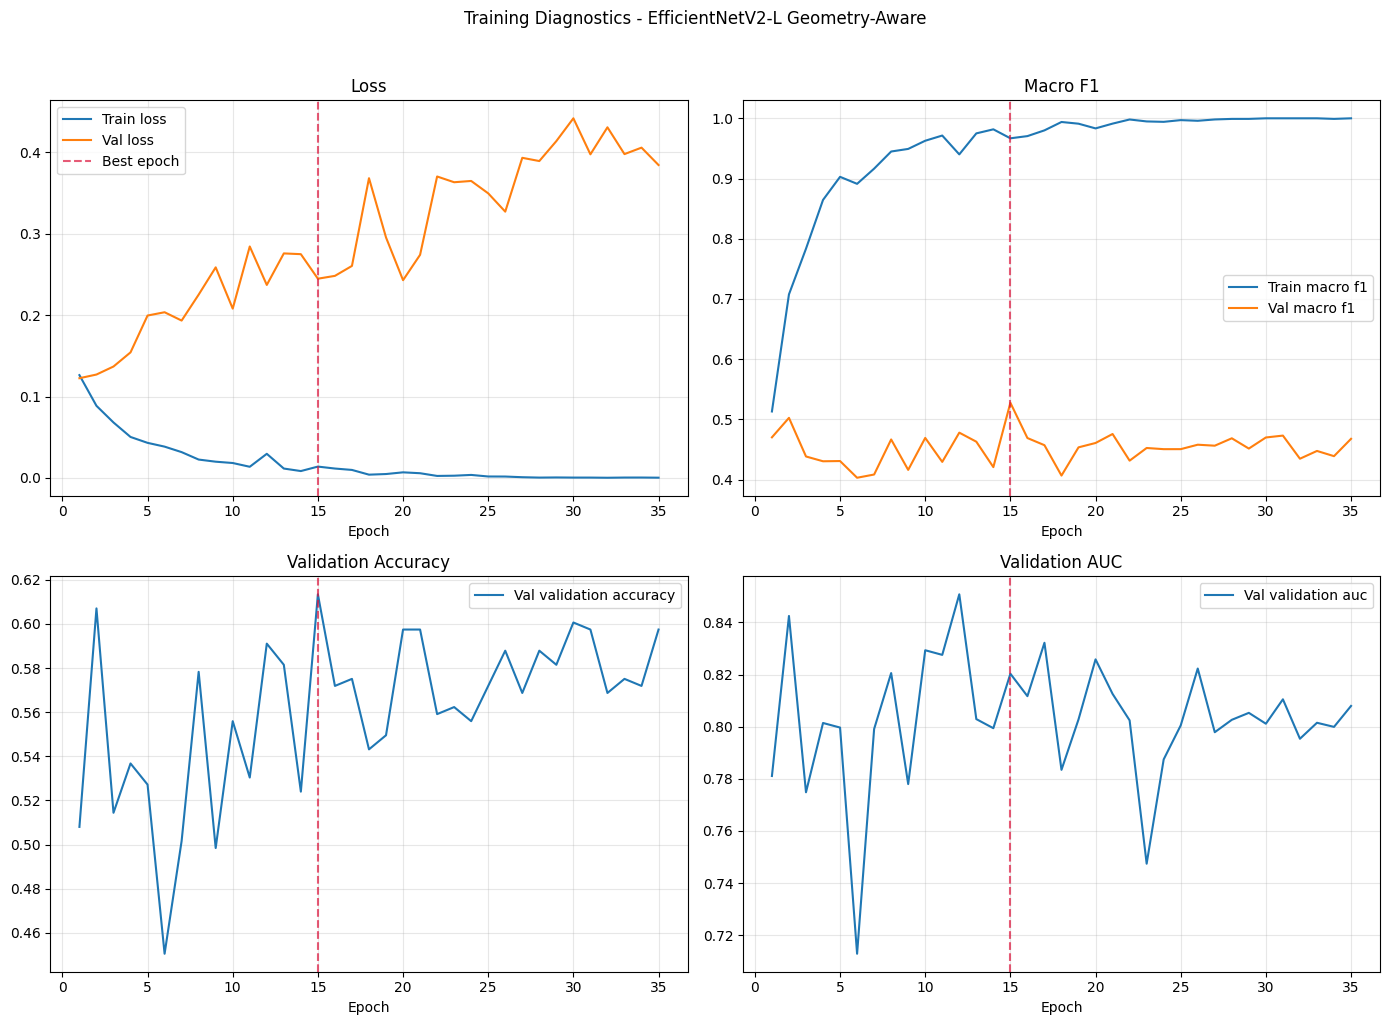

In [ ]:
history_path = os.path.join(RESULTS_DIR, 'training_history_efficientnet_v2_l_pretrained.csv')
checkpoint_path = os.path.join(MODELS_DIR, 'best_efficientnet_v2_l_pretrained.pth')

history_df = globals().get('history_df')
if history_df is None or (hasattr(history_df, 'empty') and history_df.empty):
    if os.path.exists(history_path):
        history_df = pd.read_csv(history_path)
    else:
        history_df = pd.DataFrame()

if not history_df.empty:
    history_df = history_df.sort_values('epoch').reset_index(drop=True)
    history_df.to_csv(history_path, index=False)

best_epoch = globals().get('best_epoch')
if best_epoch is None and not history_df.empty:
    best_epoch = int(history_df.loc[history_df['val_macro_f1'].idxmax(), 'epoch'])
best_val_f1 = globals().get('best_val_f1')
if best_val_f1 is None and not history_df.empty:
    best_val_f1 = float(history_df['val_macro_f1'].max())

model = globals().get('model')
if model is None:
    model = build_efficientnet_v2_l(len(class_names), pretrained=USE_PRETRAINED).to(device)
    if os.path.exists(checkpoint_path):
        model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model.eval()

print('Best epoch:', best_epoch)
print('Best val macro F1:', best_val_f1)
if not history_df.empty:
    display(history_df.tail())

# Plot diagnostics
plot_cols = [
    ('train_loss', 'val_loss', 'Loss'),
    ('train_macro_f1', 'val_macro_f1', 'Macro F1'),
    (None, 'val_accuracy', 'Validation Accuracy'),
    (None, 'val_auc', 'Validation AUC'),
]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()
for ax, (train_col, val_col, title) in zip(axes, plot_cols):
    if train_col is not None and train_col in history_df.columns:
        ax.plot(history_df['epoch'], history_df[train_col], label=f'Train {title.lower()}')
    if val_col in history_df.columns:
        ax.plot(history_df['epoch'], history_df[val_col], label=f'Val {title.lower()}')
    if best_epoch is not None:
        ax.axvline(best_epoch, color='crimson', linestyle='--', alpha=0.7, label='Best epoch' if ax is axes[0] else None)
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.grid(alpha=0.3)
    ax.legend()
fig.suptitle('Training Diagnostics - EfficientNetV2-L Pretrained', y=1.02)
plt.tight_layout()
if not history_df.empty:
    plt.savefig(os.path.join(RESULTS_DIR, 'training_diagnostics_efficientnet_v2_l_pretrained.png'), dpi=200, bbox_inches='tight')
plt.show()

# Re-evaluate with standard cross-entropy, which matches class-index targets.
criterion = nn.CrossEntropyLoss(weight=class_weights)
if 'test_metrics' not in globals() or 'y_true' not in globals() or 'y_prob' not in globals():
    test_metrics, y_true, y_pred, y_prob = evaluate(model, test_loader, criterion)

TEST METRICS (global)
  accuracy                      : 0.7441
  balanced_accuracy             : 0.6453
  macro_f1                      : 0.6344
  macro_precision               : 0.6513
  macro_recall                  : 0.6453
  roc_auc_ovo_macro             : 0.8841
  pr_auc_macro                  : 0.6809
  loss                          : 0.1387

PER-CLASS METRICS
               precision    recall  f1-score   support

Biliary Leaks     0.4000    0.2222    0.2857        18
    Lithiasis     0.7823    0.8362    0.8083       116
       Normal     0.5800    0.8286    0.6824        35
    Stricture     0.8429    0.6941    0.7613        85

     accuracy                         0.7441       254
    macro avg     0.6513    0.6453    0.6344       254
 weighted avg     0.7476    0.7441    0.7382       254


Per-class summary table:


,Precision,Recall,F1-score,Support
Biliary Leaks,0.4000,0.2222,0.2857,18
Lithiasis,0.7823,0.8362,0.8083,116
Normal,0.5800,0.8286,0.6824,35
Stricture,0.8429,0.6941,0.7613,85



Averages:


,Precision,Recall,F1-score
macro avg,0.6513,0.6453,0.6344
weighted avg,0.7476,0.7441,0.7382


,model,geometry_mode,use_clahe,test_accuracy,test_balanced_accuracy,test_macro_f1,test_macro_precision,test_macro_recall,test_roc_auc_ovo_macro,test_pr_auc_macro,...,test_Normal_f1,test_Stricture_f1,test_Biliary Leaks_precision,test_Lithiasis_precision,test_Normal_precision,test_Stricture_precision,test_Biliary Leaks_recall,test_Lithiasis_recall,test_Normal_recall,test_Stricture_recall
0,efficientnet_v2_l_scratch,direct_resize,True,0.744094,0.64528,0.634423,0.651279,0.64528,0.884087,0.680853,...,0.682353,0.76129,0.4,0.782258,0.58,0.842857,0.222222,0.836207,0.828571,0.694118


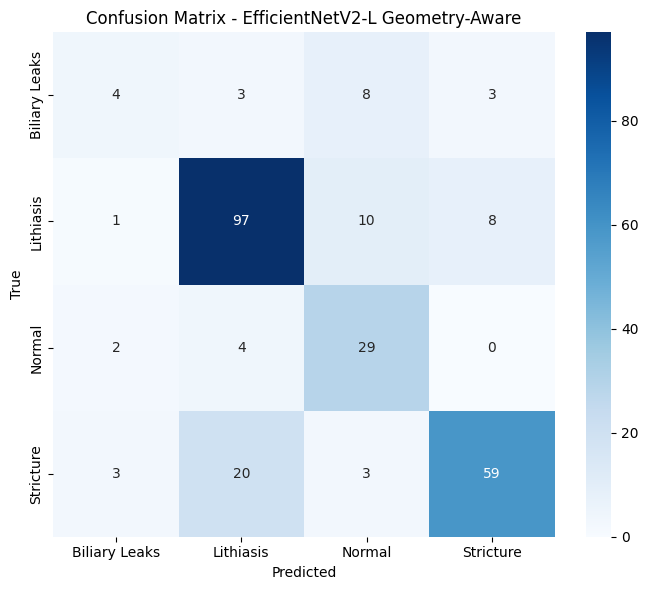

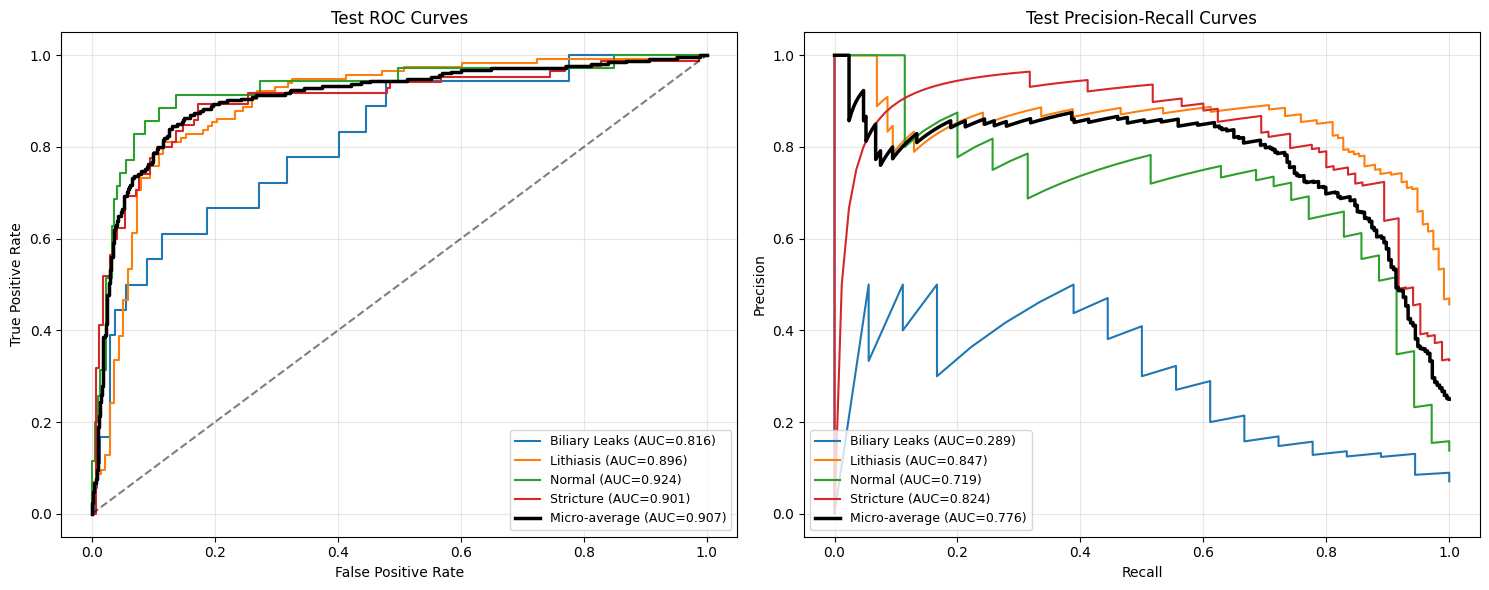

In [ ]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc

checkpoint_path = os.path.join(MODELS_DIR, 'best_efficientnet_v2_l_pretrained.pth')
model = globals().get('model')
if model is None:
    model = build_efficientnet_v2_l(len(class_names), pretrained=USE_PRETRAINED).to(device)
    if os.path.exists(checkpoint_path):
        model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model.eval()

criterion = FocalLoss()
test_metrics = globals().get('test_metrics')
y_true = globals().get('y_true')
y_pred = globals().get('y_pred')
y_prob = globals().get('y_prob')
if test_metrics is None or y_true is None or y_prob is None:
    test_metrics, y_true, y_pred, y_prob = evaluate(model, test_loader, criterion)

# ── Global (macro) metrics ───────────────────────────────────────────────
print('=' * 60)
print('TEST METRICS (global)')
print('=' * 60)
for k, v in test_metrics.items():
    print(f'  {k:<30s}: {v:.4f}' if isinstance(v, (float, np.floating)) else f'  {k}: {v}')

# ── Per-class detailed report ────────────────────────────────────────────
report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True, zero_division=0)
cm = confusion_matrix(y_true, y_pred)

print('\n' + '=' * 60)
print('PER-CLASS METRICS')
print('=' * 60)
print(classification_report(y_true, y_pred, target_names=class_names, digits=4, zero_division=0))

# Styled per-class DataFrame
report_df = pd.DataFrame(report).transpose()
per_class_df = report_df.loc[class_names, ['precision', 'recall', 'f1-score', 'support']].copy()
per_class_df.columns = ['Precision', 'Recall', 'F1-score', 'Support']
per_class_df['Support'] = per_class_df['Support'].astype(int)
print('\nPer-class summary table:')
display(per_class_df.style
    .format({'Precision': '{:.4f}', 'Recall': '{:.4f}', 'F1-score': '{:.4f}'})
    .background_gradient(subset=['F1-score'], cmap='RdYlGn', vmin=0, vmax=1)
    .set_caption('Per-class Precision / Recall / F1 (test set)'))

avg_rows = ['macro avg', 'weighted avg']
avg_df = report_df.loc[[r for r in avg_rows if r in report_df.index],
                        ['precision', 'recall', 'f1-score']].copy()
avg_df.columns = ['Precision', 'Recall', 'F1-score']
print('\nAverages:')
display(avg_df.style.format('{:.4f}').set_caption('Macro & Weighted averages'))

# Save reports
with open(os.path.join(RESULTS_DIR, 'classification_report_efficientnet_v2_l_pretrained.json'), 'w') as f:
    json.dump(report, f, indent=2)
report_df.to_csv(os.path.join(RESULTS_DIR, 'classification_report_efficientnet_v2_l_pretrained.csv'))
pd.DataFrame(cm, index=class_names, columns=class_names).to_csv(os.path.join(RESULTS_DIR, 'confusion_matrix_efficientnet_v2_l_pretrained.csv'))

summary = pd.DataFrame([{ 
    'model': 'efficientnet_v2_l_pretrained',
    'geometry_mode': GEOMETRY_MODE,
    'use_clahe': USE_CLAHE,
    **{f'test_{k}': v for k, v in test_metrics.items()},
    **{f'test_{cls}_f1': report[cls]['f1-score'] for cls in class_names},
    **{f'test_{cls}_precision': report[cls]['precision'] for cls in class_names},
    **{f'test_{cls}_recall': report[cls]['recall'] for cls in class_names},
}])
summary.to_csv(os.path.join(RESULTS_DIR, 'test_summary_efficientnet_v2_l_pretrained.csv'), index=False)
display(summary)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - EfficientNetV2-L Pretrained')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'confusion_matrix_efficientnet_v2_l_pretrained.png'), dpi=200, bbox_inches='tight')
plt.show()


y_true_bin = label_binarize(y_true, classes=list(range(len(class_names))))
fpr_micro, tpr_micro, _ = roc_curve(y_true_bin.ravel(), y_prob.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for idx, class_name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_true_bin[:, idx], y_prob[:, idx])
    roc_auc_value = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, label=f'{class_name} (AUC={roc_auc_value:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0].plot(fpr_micro, tpr_micro, label=f'Micro-average (AUC={roc_auc_micro:.3f})', linewidth=2.5, color='black')
axes[0].set_title('Test ROC Curves')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

precision_micro, recall_micro, _ = precision_recall_curve(y_true_bin.ravel(), y_prob.ravel())
pr_auc_micro = auc(recall_micro, precision_micro)
for idx, class_name in enumerate(class_names):
    precision, recall, _ = precision_recall_curve(y_true_bin[:, idx], y_prob[:, idx])
    pr_auc_value = auc(recall, precision)
    axes[1].plot(recall, precision, label=f'{class_name} (AUC={pr_auc_value:.3f})')
axes[1].plot(recall_micro, precision_micro, label=f'Micro-average (AUC={pr_auc_micro:.3f})', linewidth=2.5, color='black')
axes[1].set_title('Test Precision-Recall Curves')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'roc_pr_curves_efficientnet_v2_l_pretrained.png'), dpi=200, bbox_inches='tight')
plt.show()


In [ ]:
# ── Baseline comparison (macro F1) ─────────────────────────────────────────
BASELINE_MACRO_F1 = 0.738   # previous best result

our_macro_f1 = test_metrics.get('macro_f1', float('nan'))
delta        = our_macro_f1 - BASELINE_MACRO_F1
pct_change   = delta / BASELINE_MACRO_F1 * 100

print("=" * 55)
print("BASELINE vs THIS MODEL")
print("=" * 55)
print(f"  Baseline macro F1   : {BASELINE_MACRO_F1:.4f}")
print(f"  This model macro F1 : {our_macro_f1:.4f}")
print(f"  Δ (absolute)        : {delta:+.4f}")
print(f"  Δ (relative)        : {pct_change:+.2f}%")
print()
if delta > 0:
    print(f"  ✓ IMPROVEMENT of {delta:+.4f} over baseline")
elif delta == 0:
    print("  = Tied with baseline")
else:
    print(f"  ✗ Below baseline by {abs(delta):.4f}")
print("=" * 55)

# Save to results
comparison_df = pd.DataFrame([{
    'model':             'efficientnet_v2_l_scratch',
    'baseline_macro_f1': BASELINE_MACRO_F1,
    'model_macro_f1':    our_macro_f1,
    'delta':             delta,
    'pct_change':        pct_change,
}])
comparison_df.to_csv(os.path.join(RESULTS_DIR, 'baseline_comparison.csv'), index=False)
display(comparison_df)


BASELINE vs THIS MODEL
  Baseline macro F1   : 0.7380
  This model macro F1 : 0.6344
  Δ (absolute)        : -0.1036
  Δ (relative)        : -14.03%

  ✗ Below baseline by 0.1036


,model,baseline_macro_f1,model_macro_f1,delta,pct_change
0,efficientnet_v2_l_scratch,0.738,0.634423,-0.103577,-14.034862


In [ ]:
# ── Per-sample probability table ────────────────────────────────────────────
# Ensure y_true, y_pred, y_prob are available (run evaluation cell if not).
y_true_local = globals().get('y_true')
y_pred_local = globals().get('y_pred')
y_prob_local = globals().get('y_prob')
if y_true_local is None:
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    test_metrics, y_true_local, y_pred_local, y_prob_local = evaluate(model, test_loader, criterion)

probs_df = pd.DataFrame(y_prob_local, columns=[f"prob_{c}" for c in class_names])
probs_df["true_label"] = [class_names[i] for i in y_true_local]
probs_df["pred_label"] = [class_names[i] for i in y_pred_local]
probs_df["correct"]    = probs_df["true_label"] == probs_df["pred_label"]

print(f"Test samples: {len(probs_df)}")
print(f"Correct predictions: {probs_df['correct'].sum()} / {len(probs_df)}")
print()
display(probs_df.head(10))

probs_df.to_csv(os.path.join(RESULTS_DIR, 'test_probabilities.csv'), index=False)
print(f"\nSaved to {os.path.join(RESULTS_DIR, 'test_probabilities.csv')}")

Test samples: 254
Correct predictions: 189 / 254



,prob_Biliary Leaks,prob_Lithiasis,prob_Normal,prob_Stricture,true_label,pred_label,correct
0,0.015995,0.005146,0.964183,0.014675,Normal,Normal,True
1,0.003125,0.000915,0.995099,0.000861,Normal,Normal,True
2,0.428622,0.126915,0.431123,0.013341,Lithiasis,Normal,False
3,0.016851,0.947385,0.032835,0.002928,Lithiasis,Lithiasis,True
4,0.034535,0.847127,0.114758,0.003580,Lithiasis,Lithiasis,True
5,0.024564,0.950492,0.014429,0.010515,Lithiasis,Lithiasis,True
6,0.014472,0.947736,0.015871,0.021922,Lithiasis,Lithiasis,True
7,0.779467,0.181584,0.034060,0.004889,Lithiasis,Biliary Leaks,False
8,0.007530,0.852603,0.054273,0.085594,Lithiasis,Lithiasis,True
9,0.001376,0.996119,0.000621,0.001884,Lithiasis,Lithiasis,True



Saved to /mounts/mecd-ap-g5/results/filter_benchmark_efficientnet_v2_l_scratch_fixed/test_probabilities.csv


In [ ]:
def _get_efficientnet_target_layer(model):
    """Return the last convolutional block of EfficientNetV2-L."""
    return model.features[-1]


class GradCAM:
    """Gradient-weighted Class Activation Mapping for any model with hooks."""

    def __init__(self, model, target_layer):
        self.model = model
        self.activations = None
        self.gradients = None
        self._handles = []
        self._handles.append(target_layer.register_forward_hook(self._save_activation))
        self._handles.append(target_layer.register_full_backward_hook(self._save_gradient))

    def _save_activation(self, _, __, output):
        self.activations = output.detach()

    def _save_gradient(self, _, _input, grad_output):
        self.gradients = grad_output[0].detach()

    def remove_hooks(self):
        for handle in self._handles:
            handle.remove()

    def __call__(self, input_tensor, target_idx):
        self.model.zero_grad(set_to_none=True)
        logits = self.model(input_tensor)
        logits[:, target_idx].sum().backward(retain_graph=True)
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = torch.relu((weights * self.activations).sum(dim=1, keepdim=True))
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        cam = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))
        return cam


def occlusion_sensitivity(model, img_tensor, target_idx, patch=24, stride=12):
    """Patch-based occlusion map — returns normalised heatmap (H×W)."""
    model.eval()
    dev = next(model.parameters()).device
    img_tensor = img_tensor.to(dev)
    with torch.no_grad():
        base_prob = torch.softmax(model(img_tensor), dim=1)[0, target_idx].item()
    _, _, h, w = img_tensor.shape
    heat = np.zeros((h, w), dtype=np.float32)
    counts = np.zeros((h, w), dtype=np.float32)
    for y in range(0, h - patch + 1, stride):
        for x in range(0, w - patch + 1, stride):
            occ = img_tensor.clone()
            occ[:, :, y : y + patch, x : x + patch] = 0.0
            with torch.no_grad():
                prob = torch.softmax(model(occ), dim=1)[0, target_idx].item()
            drop = base_prob - prob
            heat[y : y + patch, x : x + patch] += drop
            counts[y : y + patch, x : x + patch] += 1.0
    heat = heat / np.maximum(counts, 1.0)
    heat = (heat - heat.min()) / (heat.max() - heat.min() + 1e-8)
    return heat


def overlay_cam(image_pil, cam, alpha=0.5):
    img = np.array(image_pil.convert('RGB'))
    heat = cv2.applyColorMap((cam * 255).astype(np.uint8), cv2.COLORMAP_JET)
    heat = cv2.cvtColor(heat, cv2.COLOR_BGR2RGB)
    return (alpha * heat + (1 - alpha) * img).astype(np.uint8)


def show_xai_grid(patch=24, stride=12):
    """4-column grid: original | occlusion overlay | Grad-CAM heatmap | Grad-CAM overlay."""
    _model = globals().get('model')
    if _model is None:
        print("Model not available — run the training/loading cell first.")
        return

    _y_true = globals().get('y_true')
    _y_pred = globals().get('y_pred')
    if _y_true is None or _y_pred is None:
        print("Run evaluation cell first to get y_true / y_pred.")
        return

    dev = next(_model.parameters()).device
    _model.eval()

    target_layer = _get_efficientnet_target_layer(_model)
    gradcam = GradCAM(_model, target_layer)

    picks = []
    for cls_idx, cls_name in enumerate(class_names):
        correct_idxs = np.where((_y_true == cls_idx) & (_y_pred == cls_idx))[0]
        if len(correct_idxs):
            picks.append((int(correct_idxs[0]), cls_name))
        else:
            print(f"  No correct prediction for class '{cls_name}' — skipping.")

    if not picks:
        print("No correct predictions found; cannot visualise.")
        return

    fig, axes = plt.subplots(len(picks), 4, figsize=(16, 4 * len(picks)))
    if len(picks) == 1:
        axes = axes[np.newaxis, :]

    for row_i, (idx, cls_name) in enumerate(picks):
        row = test_ds.samples[idx]
        img_pil = Image.open(row[0]).convert('RGB')
        proc = preprocess_image(img_pil, geometry_mode=GEOMETRY_MODE, use_clahe=USE_CLAHE)

        img_t = eval_transform(proc).unsqueeze(0).to(dev)
        pred_idx = int(_y_pred[idx])

        cam = gradcam(img_t, pred_idx)
        cam_overlay = overlay_cam(proc, cam)

        occl = occlusion_sensitivity(_model, img_t, pred_idx, patch=patch, stride=stride)

        axes[row_i, 0].imshow(proc)
        axes[row_i, 0].set_title(f"Original\n[{cls_name}]", fontsize=9)
        axes[row_i, 0].axis('off')

        ax1 = axes[row_i, 1]
        ax1.imshow(proc)
        ax1.imshow(occl, cmap='inferno', alpha=0.55)
        ax1.set_title('Occlusion overlay', fontsize=9)
        ax1.axis('off')

        axes[row_i, 2].imshow(cam, cmap='jet')
        axes[row_i, 2].set_title('Grad-CAM heatmap', fontsize=9)
        axes[row_i, 2].axis('off')

        axes[row_i, 3].imshow(cam_overlay)
        axes[row_i, 3].set_title('Grad-CAM overlay', fontsize=9)
        axes[row_i, 3].axis('off')

    plt.suptitle('XAI: Grad-CAM + Occlusion — EfficientNetV2-L (one correct example per class)', fontsize=12, y=1.01)
    plt.tight_layout()
    save_path = os.path.join(RESULTS_DIR, 'xai_gradcam_occlusion_pretrained.png')
    plt.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.show()
    print(f"\nSaved to {save_path}")
    gradcam.remove_hooks()


# ── Run
show_xai_grid(patch=16, stride=8)